In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_id = "1m41TK2iuti6YuYiPfH1WUq7S99UQL3Mu"
download_path = "/content/drive/MyDrive/dataset.zip"

In [ ]:
!pip install gdown
import gdown
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, download_path, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1m41TK2iuti6YuYiPfH1WUq7S99UQL3Mu
From (redirected): https://drive.google.com/uc?id=1m41TK2iuti6YuYiPfH1WUq7S99UQL3Mu&confirm=t&uuid=bf021ef0-c368-4707-9744-302c7f6d1ea7
To: /content/drive/MyDrive/dataset.zip
100%|██████████| 323M/323M [00:07<00:00, 46.1MB/s]


'/content/drive/MyDrive/dataset.zip'

In [ ]:
!unzip /content/drive/MyDrive/dataset.zip -q


Archive:  /content/drive/MyDrive/dataset.zip
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692332350433.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692332350457.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692333303178.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692333631862.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692333631989.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/1692335403904.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/20230815_111239.jpg  
  inflating: Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment/Images/Bacteria/20230815_111300.jpg  
  inflating: Dataset/Potato Leaf Disease Datase

In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, Input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    InputLayer,
    Flatten
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import ResNet50

# Scikit-learn
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_curve
)
import joblib
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import label_binarize
from tqdm import tqdm

# Visualization
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
IMAGE_SIZE = 224
CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 100
BASE_DIR = "/content/combined_dataset"


In [ ]:
import os
import shutil
import random

random.seed(42)

DATASET_ROOT = "/content/Dataset/Potato Leaf Disease Dataset in Uncontrolled Environment"
DEST_DIR = "/content/combined_dataset"
TEST_SPLIT_RATIO = 0.2

IMAGE_DIR = os.path.join(DATASET_ROOT, "Images")
MASK_DIR  = os.path.join(DATASET_ROOT, "Objects")

print("Images dir exists:", os.path.exists(IMAGE_DIR))
print("Masks dir exists:", os.path.exists(MASK_DIR))

CLASSES = [
    d for d in os.listdir(IMAGE_DIR)
    if os.path.isdir(os.path.join(IMAGE_DIR, d))
]

print("Detected classes:", CLASSES)


if os.path.exists(DEST_DIR):
    shutil.rmtree(DEST_DIR)
for split in ["train", "test"]:
    for sub in ["images", "masks"]:
        for cls in CLASSES:
            os.makedirs(
                os.path.join(DEST_DIR, split, sub, cls),
                exist_ok=True
            )

def find_mask(mask_dir, image_fname):
    base = os.path.splitext(image_fname)[0]
    for ext in [".png", ".jpg", ".jpeg"]:
        mask_path = os.path.join(mask_dir, base + ext)
        if os.path.exists(mask_path):
            return mask_path
    return None

skipped = 0

for cls in CLASSES:
    img_cls_dir = os.path.join(IMAGE_DIR, cls)
    mask_cls_dir = os.path.join(MASK_DIR, cls)

    images = sorted([
        f for f in os.listdir(img_cls_dir)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

    random.shuffle(images)
    test_count = max(1, int(len(images) * TEST_SPLIT_RATIO))

    test_imgs = images[:test_count]
    train_imgs = images[test_count:]

    # ---- TRAIN ----
    for fname in train_imgs:
        img_src = os.path.join(img_cls_dir, fname)
        mask_src = find_mask(mask_cls_dir, fname)

        if mask_src is None:
            skipped += 1
            continue

        shutil.copy(
            img_src,
            os.path.join(DEST_DIR, "train", "images", cls, fname)
        )
        shutil.copy(
            mask_src,
            os.path.join(
                DEST_DIR,
                "train",
                "masks",
                cls,
                os.path.basename(mask_src)
            )
        )

    # ---- TEST ----
    for fname in test_imgs:
        img_src = os.path.join(img_cls_dir, fname)
        mask_src = find_mask(mask_cls_dir, fname)

        if mask_src is None:
            skipped += 1
            continue

        shutil.copy(
            img_src,
            os.path.join(DEST_DIR, "test", "images", cls, fname)
        )
        shutil.copy(
            mask_src,
            os.path.join(
                DEST_DIR,
                "test",
                "masks",
                cls,
                os.path.basename(mask_src)
            )
        )

print(" Train/test split completed correctly")
print(f" Skipped {skipped} images without matching masks")

Images dir exists: True
Masks dir exists: True
Detected classes: ['Nematode', 'Bacteria', 'Healthy', 'Phytopthora', 'Fungi', 'Pest', 'Virus']
Train/test split completed correctly
Skipped 0 images without matching masks


In [ ]:

import tensorflow as tf
import os

def load_image_mask(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(
        img, channels=3, try_recover_truncated=True
    )
    img = tf.image.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, (IMAGE_SIZE, IMAGE_SIZE),
                            method="nearest")
    mask = tf.cast(mask, tf.float32)

    return img, mask

def get_paths(split):
    img_paths = []
    mask_paths = []

    images_root = os.path.join(BASE_DIR, split, "images")
    masks_root  = os.path.join(BASE_DIR, split, "masks")

    for cls in os.listdir(images_root):
        img_dir = os.path.join(images_root, cls)
        mask_dir = os.path.join(masks_root, cls)

        for fname in os.listdir(img_dir):
            if fname.lower().endswith((".jpg", ".jpeg", ".png")):
                img_path = os.path.join(img_dir, fname)

                base = os.path.splitext(fname)[0]
                for ext in [".png", ".jpg", ".jpeg"]:
                    candidate = os.path.join(mask_dir, base + ext)
                    if os.path.exists(candidate):
                        img_paths.append(img_path)
                        mask_paths.append(candidate)
                        break

    return img_paths, mask_paths

train_img_paths, train_mask_paths = get_paths("train")

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_img_paths, train_mask_paths)
)

train_ds = train_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds = train_ds.shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_img_paths, val_mask_paths = get_paths("test")

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_img_paths, val_mask_paths)
)

val_ds = val_ds.map(
    load_image_mask,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)



In [ ]:
train_img_paths, train_mask_paths = get_paths("train")

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_img_paths, train_mask_paths)
)

train_ds = train_ds.map(load_image_mask,
                        num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(100).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_img_paths, val_mask_paths = get_paths("test")

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_img_paths, val_mask_paths)
)

val_ds = val_ds.map(load_image_mask,
                    num_parallel_calls=tf.data.AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [ ]:
class_names = train_ds.class_names
class_names

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']

In [ ]:
plt.savefig("three_images_collage.png")

<Figure size 640x480 with 0 Axes>

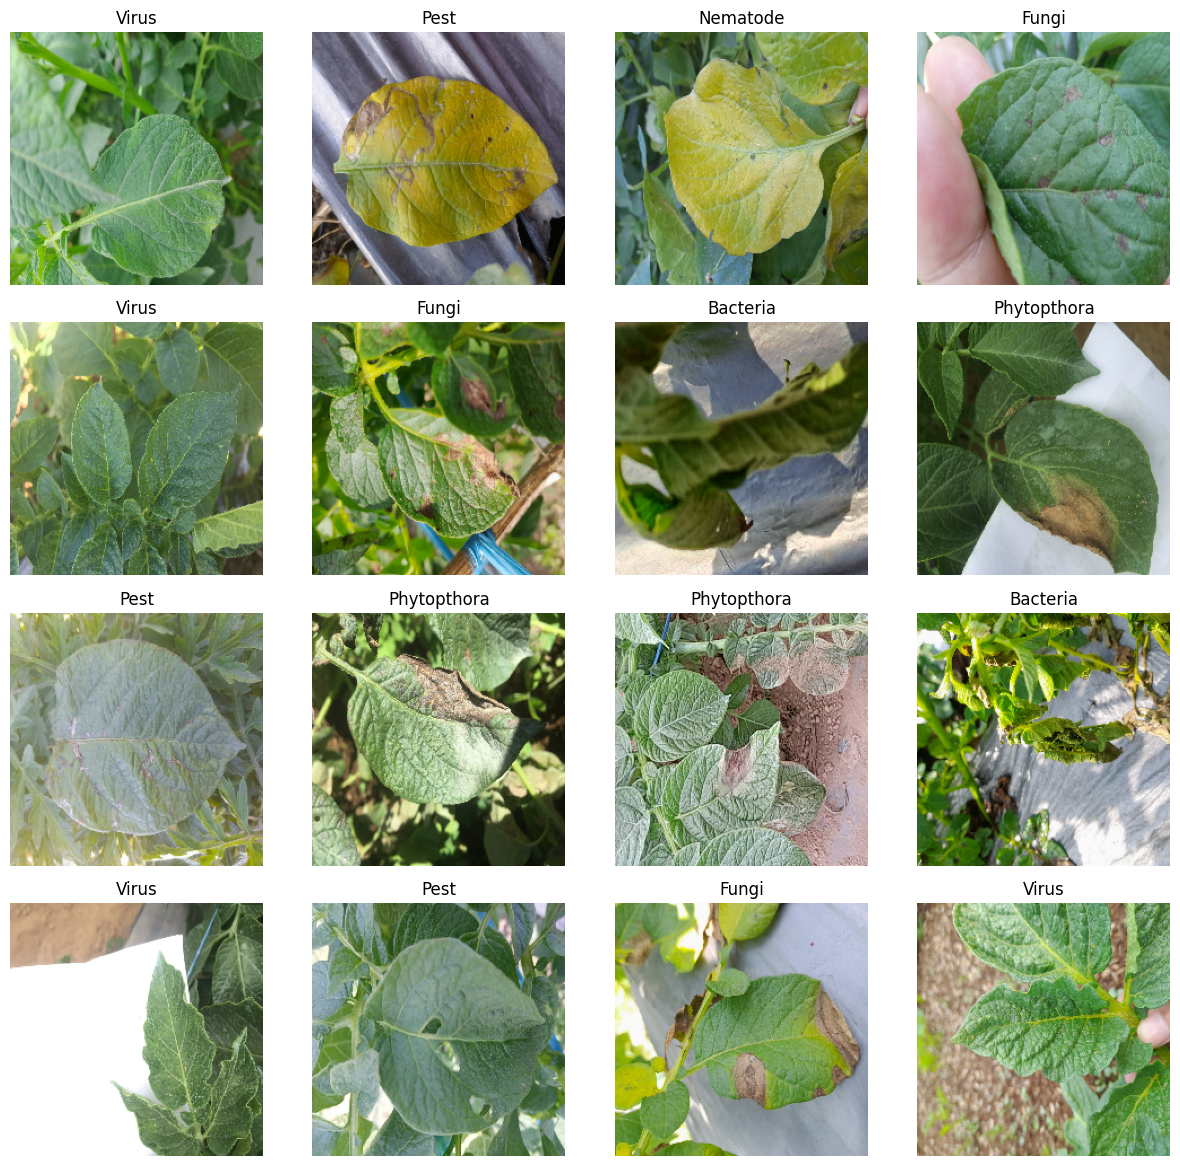

In [ ]:
plt.figure(figsize=(12, 12))
for batch_images, batch_labels in train_ds.take(1):
    for i in range(16):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(batch_images[i].numpy().astype("uint8"))
        plt.title(class_names[batch_labels[i]])
        plt.tight_layout()
        plt.axis("off")


In [ ]:
resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
  layers.Rescaling(1./255),
])

In [ ]:
data_augmentation = tf.keras.Sequential([
  layers.RandomRotation(0.2),
  layers.RandomFlip(seed = 42)
])

In [ ]:
train_data = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import (
    Input, Conv2D, Conv2DTranspose,
    Concatenate, GlobalAveragePooling2D, Dense
)
from tensorflow.keras.models import Model

IMAGE_SIZE = 224
CHANNELS = 3
n_classes = len(class_names)
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

inputs = Input(shape=input_shape)

base_model = ResNet50(
    include_top=False,
    weights="imagenet",
    input_tensor=inputs
)

# Skip connections
s1 = base_model.get_layer("conv1_relu").output          # 112x112
s2 = base_model.get_layer("conv2_block3_out").output   # 56x56
s3 = base_model.get_layer("conv3_block4_out").output   # 28x28
s4 = base_model.get_layer("conv4_block6_out").output   # 14x14

# Bridge
x = base_model.get_layer("conv5_block3_out").output    # 7x7

def upsample(x, skip, filters):
    x = Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = Concatenate()([x, skip])
    x = Conv2D(filters, 3, activation="relu", padding="same")(x)
    x = Conv2D(filters, 3, activation="relu", padding="same")(x)
    return x

x = upsample(x, s4, 512)
x = upsample(x, s3, 256)
x = upsample(x, s2, 128)
x = upsample(x, s1, 64)

segmentation_output = Conv2D(
    1, 1, activation="sigmoid", name="segmentation"
)(x)

cls = GlobalAveragePooling2D()(x)
cls = Dense(128, activation="relu")(cls)
classification_output = Dense(
    n_classes, activation="softmax", name="classification"
)(cls)

model = Model(
    inputs=inputs,
    outputs=[classification_output, segmentation_output],
    name="ResNet50_UNet_Classifier"
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss={
        "classification": tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)
    },
    metrics={
        "classification": ["accuracy"]
    }
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath="unet_classification_model.keras",
        monitor="val_classification_accuracy",
        save_best_only=True,
        verbose=1
    )
]

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train
history = model.fit(
    train_data,
    validation_data=val_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    callbacks=callback
)


Epoch 1/100


I0000 00:00:1757769695.015585      73 service.cc:148] XLA service 0x7dc9740027d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757769695.016187      73 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757769700.094091      73 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1757769732.123816      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


405/405 ━━━━━━━━━━━━━━━━━━━━ 262s 428ms/step - accuracy: 0.5026 - loss: 1.2889 - val_accuracy: 0.4340 - val_loss: 1.8013
Epoch 2/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 131s 321ms/step - accuracy: 0.6617 - loss: 0.9136 - val_accuracy: 0.5520 - val_loss: 1.1094
Epoch 3/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 128s 315ms/step - accuracy: 0.7154 - loss: 0.7806 - val_accuracy: 0.6615 - val_loss: 0.9983
Epoch 4/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 128s 315ms/step - accuracy: 0.7670 - loss: 0.6718 - val_accuracy: 0.6854 - val_loss: 0.9236
Epoch 5/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 129s 316ms/step - accuracy: 0.8060 - loss: 0.5685 - val_accuracy: 0.7205 - val_loss: 0.7999
Epoch 6/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 129s 317ms/step - accuracy: 0.8237 - loss: 0.5082 - val_accuracy: 0.7669 - val_loss: 0.6562
Epoch 7/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 129s 316ms/step - accuracy: 0.8454 - loss: 0.4530 - val_accuracy: 0.7893 - val_loss: 0.6512
Epoch 8/100
405/405 ━━━━━━━━━━━━━━━━━━━━ 129s 317ms/step - accuracy: 0.8554 - los

In [ ]:
# ===============================
#  Model Complexity & Performance
# ===============================

import tensorflow as tf
import numpy as np
import time
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2


# 2️⃣ FLOPs calculation (TF graph mode, works on TF 2.15 Kaggle)
concrete_func = tf.function(lambda inputs: model(inputs))
concrete_func = concrete_func.get_concrete_function(
    tf.TensorSpec([1, IMAGE_SIZE, IMAGE_SIZE, 3], tf.float32)
)

# Freeze model graph
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph_def = frozen_func.graph.as_graph_def()

# Use tf.compat.v1.profiler
run_meta = tf.compat.v1.RunMetadata()
opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

flops = tf.compat.v1.profiler.profile(
    graph=frozen_func.graph,
    run_meta=run_meta,
    cmd='op',
    options=opts
)

if flops is not None:
    print(f"\nTotal FLOPs: {flops.total_float_ops / 10**9:.3f} GFLOPs (for batch_size=1)")
else:
    print("Could not compute FLOPs.")

# 3️⃣ Training time per epoch (define a callback before training)
class EpochTimeCallback(tf.keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self.epoch_start = time.time()
    def on_epoch_end(self, epoch, logs=None):
        duration = time.time() - self.epoch_start
        print(f"Epoch {epoch+1} training time: {duration:.2f} seconds")

# Example usage during training:
# history = model.fit(
#     train_data,
#     validation_data=val_ds,
#     epochs=EPOCHS,
#     batch_size=BATCH_SIZE,
#     verbose=1,
#     callbacks=[callback, EpochTimeCallback()]
# )

# 4️⃣ Inference time (latency, single image)
dummy_input = np.random.rand(1, IMAGE_SIZE, IMAGE_SIZE, 3).astype(np.float32)

# Warm-up
_ = model.predict(dummy_input)

# Timed run
start = time.time()
_ = model.predict(dummy_input)
end = time.time()

print(f"Inference time: {(end-start)*1000:.2f} ms per image (batch=1)")

# 5️⃣ Throughput test (batch=32)
dummy_input_batch = np.random.rand(32, IMAGE_SIZE, IMAGE_SIZE, 3).astype(np.float32)

start = time.time()
_ = model.predict(dummy_input_batch)
end = time.time()

print(f"Throughput: {32 / (end-start):.2f} images/sec (batch=32)")


I0000 00:00:1757782814.840209      19 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1757782814.840474      19 single_machine.cc:361] Starting new session
I0000 00:00:1757782814.841621      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0



=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
op: The nodes are operation kernel type, such as MatMul, Conv2D. Graph nodes belonging to the same type are aggregated together.
flops: Number of float operations. Note: Please read the implementation for th

In [ ]:
# model = load_model('model.keras')

In [ ]:
all_predictions = []
all_labels = []
for images, labels in tqdm(val_ds):
    predictions = model.predict(images, verbose = 0)
    predicted_classes = np.argmax(predictions, axis=1)
    all_predictions.extend(predicted_classes)
    all_labels.extend(labels.numpy())

100%|██████████| 23/23 [00:06<00:00,  3.31it/s]


In [ ]:
accuracy = accuracy_score(all_labels, all_predictions)
f1 = f1_score(all_labels, all_predictions, average='weighted')
recall = recall_score(all_labels, all_predictions, average='weighted')
precision = precision_score(all_labels, all_predictions, average='weighted')

print("Accuracy: ", accuracy)
print("F1 Score: ", f1)
print("Recall: ", recall)
print("Precision: ", precision)

Accuracy:  0.9859550561797753
F1 Score:  0.9859605651272217
Recall:  0.9859550561797753
Precision:  0.9865267423669438


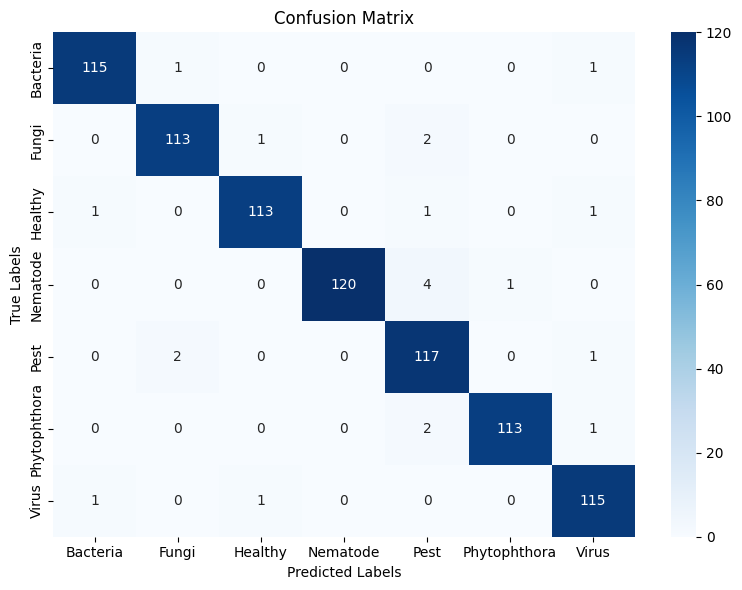

In [ ]:
conf_matrix = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.savefig('Confusion Matrix.png', dpi = 300)
plt.show()


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

from scipy.ndimage import gaussian_filter1d

sacc = gaussian_filter1d(acc, sigma=2)
sval_acc = gaussian_filter1d(val_acc, sigma=2)

sloss = gaussian_filter1d(loss, sigma=2)
sval_loss = gaussian_filter1d(val_loss, sigma=2)

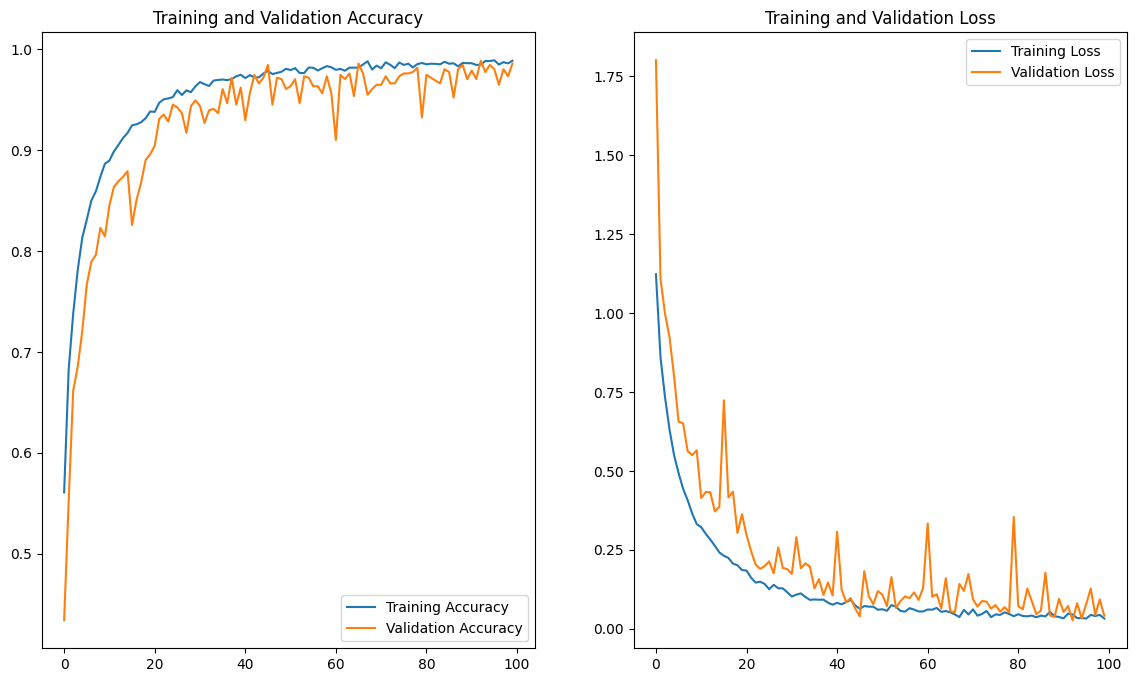

In [ ]:
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.savefig('curves.png', dpi = 300)
plt.show()

In [ ]:
def predict(model, image):
    img_array = tf.keras.preprocessing.image.img_to_array(image.numpy())
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array, verbose = 0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

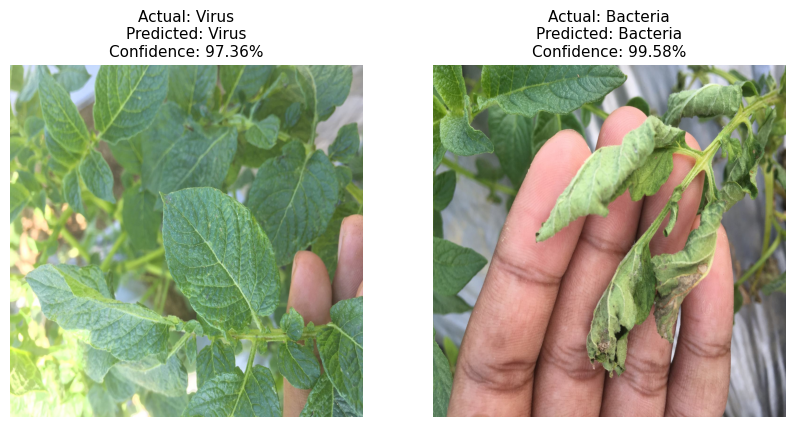

In [ ]:
plt.clf()
plt.figure(figsize=(8, 8))
for images, labels in val_ds.take(6):
    for i in range(2):
        ax = plt.subplot(2, 2, i + 1)
        if i < len(images):
            ax.imshow(images[i].numpy().astype("uint8"))

            predicted_class, confidence = predict(model, images[i])
            actual_class = class_names[labels[i]]

            ax.set_title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")
            ax.axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Save final model after training
model.save("unet_classification_final.keras")
